# MNIST Classification and Clustering

> This project was originally completed as part of university coursework and has been reorganised and documented for professional portfolio presentation.

This notebook compares Logistic Regression and RBF SVM models for binary digit classification, then explores variation within digit 7 using PCA and K-Means clustering.

## Dataset access and dependencies

The NPZ subset is excluded until its provenance and redistribution terms are documented. Set `MNIST_SUBSET_PATH` to a lawful local copy. Required libraries are NumPy, Pandas, Matplotlib, Seaborn and scikit-learn.

## Verified evaluation context

Logistic Regression achieved mean five-fold cross-validation F1 of 1.0000 and RBF SVM achieved approximately 0.9699. These are training and cross-validation results; no held-out classifier test evaluation was completed. The clustering test subset contains 100 digit-1 and 900 digit-7 images.


In [ ]:
from pathlib import Path
import os

working_directory = Path.cwd().resolve()
project_directory = working_directory.parent if working_directory.name == "notebooks" else working_directory
data_file = Path(os.environ.get("MNIST_SUBSET_PATH", project_directory / "data" / "raw" / "mnist_1_7_subsets.npz"))
output_directory = project_directory / "figures"
results_directory = project_directory / "results"

if not data_file.exists():
    raise FileNotFoundError(
        "The MNIST subset is not distributed in this repository. "
        "Set MNIST_SUBSET_PATH to a lawful local NPZ copy. "
        f"Missing: {data_file}"
    )

output_directory.mkdir(parents=True, exist_ok=True)
results_directory.mkdir(parents=True, exist_ok=True)


#### Imports and Output Folder


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans

from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    silhouette_score
)

from scipy.spatial.distance import cdist

# Use a clean visual style for plots
plt.style.use("seaborn-v0_8")

# Create a folder to save all downloadable charts and tables
output_folder = str(output_directory)
os.makedirs(output_folder, exist_ok=True)


#### Functions


In [ ]:
def save_current_plot(file_name):
    """
    This will save the current matplotlib figure as a PNG file to use in the paper.
    bbox_inches='tight' avoids cutting off labels or titles.
    """
    
    file_path = os.path.join(output_folder, file_name)
    plt.savefig(file_path, dpi=300, bbox_inches="tight")
    print(f"Saved chart: {file_path}")


def save_table(dataframe, file_name):
    """
    This will save a pandas DataFrame as a CSV file again to to use in the paper.
    This makes the table downloadable and reusable.
    """
    
    file_path = os.path.join(output_folder, file_name)
    dataframe.to_csv(file_path, index=False)
    print(f"Saved table: {file_path}")


def show_digit_samples(image_data, label_data, sample_count=10):
    """
    This will display a small group of handwritten digit images.
    It will helps us visually understand what the dataset contains.
    """
    
    rows = 2
    cols = sample_count // 2
    
    fig, axes = plt.subplots(rows, cols, figsize=(10, 5))
    
    for index, ax in enumerate(axes.flat):
        
    # Each image is reshaped back to 28x28 pixels before plotting
        digit_image = image_data[index].reshape(28, 28)
        
        ax.imshow(digit_image, cmap="gray")
        ax.set_title(f"Label: {label_data[index]}")
        ax.axis("off")
    
    plt.suptitle("Sample MNIST Digit Images")
    plt.tight_layout()
    
    save_current_plot("sample_mnist_digit_images.png")
    plt.show()



def plot_confusion_mat(true_labels, predicted_labels, chart_title, file_name):
    
    
    # Generate confusion matrix
    
    matrix = confusion_matrix(true_labels, predicted_labels)

    # Create figure
    plt.figure(figsize=(6, 5))
    
    sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[1, 7],
            yticklabels=[1, 7]
    )


    # Professional title
    plt.title(
        chart_title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    # Axis labels
    plt.xlabel(
        "Predicted Label",
        fontsize=12,
        fontweight="bold",
        labelpad=10
    )

    plt.ylabel(
        "True Label",
        fontsize=12,
        fontweight="bold",
        labelpad=10
    )

    # Tick styling
    plt.xticks(
        fontsize=10,
        fontweight="bold"
    )

    plt.yticks(
        fontsize=10,
        fontweight="bold",
        rotation=0
    )

    # Tight layout for cleaner spacing
    plt.tight_layout()

    # Save figure
    save_current_plot(file_name)

    # Show figure
    plt.show()
    
    

def plot_hyperparameter_heatmap(score_table, chart_title, file_name):
    

    plt.figure(figsize=(8, 5))

    sns.heatmap(
        score_table,
        annot=True,
        fmt=".3f",
        cmap="Blues",
        cbar=True,
        linewidths=1.2,
        linecolor="white",
        annot_kws={
            "size": 12,
            "weight": "bold"
        },
        cbar_kws={
            "label": "Mean CV F1-score",
            "shrink": 0.85
        }
    )

    plt.title(
        chart_title,
        fontsize=15,
        fontweight="bold",
        pad=14
    )

    plt.xlabel(
        "C Value",
        fontsize=12,
        fontweight="bold",
        labelpad=10
    )

    plt.ylabel(
        "Gamma Value",
        fontsize=12,
        fontweight="bold",
        labelpad=10
    )

    plt.xticks(fontsize=10, fontweight="bold")
    plt.yticks(fontsize=10, fontweight="bold", rotation=0)

    plt.tight_layout()

    save_current_plot(file_name)

    plt.show()

def evaluate_digit_classifier(true_labels, predicted_labels, model_name):
    """
    Printing the main classification metrics for a model.
    The positive class is set as digit 7.
    """
    
    print(f"\n{model_name} Performance")
    print("-" * 40)
    
    print("Accuracy:", accuracy_score(true_labels, predicted_labels))
    print("Precision:", precision_score(true_labels, predicted_labels, pos_label=7))
    print("Recall:", recall_score(true_labels, predicted_labels, pos_label=7))
    print("F1-score:", f1_score(true_labels, predicted_labels, pos_label=7))
    
    print("\nClassification Report:")
    print(classification_report(true_labels, predicted_labels))


def run_cross_validation(model, feature_data, label_data, cv_strategy, model_name):
    """
    Here running a 5-fold stratified cross-validation.
    F1 macro is used because it treats both classes equally.
    """
    
    cv_scores = cross_val_score(
        model,
        feature_data,
        label_data,
        cv=cv_strategy,
        scoring="f1_macro"
    )
    
    print(f"\n{model_name} Cross-Validation Results")
    print("-" * 40)
    print("CV F1 Scores:", cv_scores)
    print("Mean CV F1-score:", cv_scores.mean())
    print("Standard Deviation:", cv_scores.std())
    
    return cv_scores


def apply_pca(feature_data, component_count=2):
    """
    Reducing high-dimensional image features into fewer components.
    PCA with 2 components is mainly used here for visualisation.
    """
    
    pca_model = PCA(n_components=component_count)
    reduced_features = pca_model.fit_transform(feature_data)
    
    return reduced_features, pca_model


def build_kmeans_model(feature_data, cluster_count):
    """
    Fitting a K-Means clustering model.
    Returns the fitted model, cluster labels, and cluster centers.
    """
    
    kmeans_model = KMeans(
        n_clusters=cluster_count,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans_model.fit_predict(feature_data)
    cluster_centers = kmeans_model.cluster_centers_
    
    return kmeans_model, cluster_labels, cluster_centers


#### Load the Dataset


In [ ]:
# Loadind the MNIST subset dataset containing digits 1 and 7
mnist_digits = np.load(data_file)

print("Available files inside dataset:", mnist_digits.files)

# Storing the training and testing data using clear variable names
train_images = mnist_digits["train_data"]
train_labels = mnist_digits["train_targets"]

test_images = mnist_digits["test_data"]
test_labels = mnist_digits["test_targets"]

# Create dataset summary table
dataset_summary = pd.DataFrame({
    "Dataset Component": [
        "Training Images",
        "Training Labels",
        "Test Images",
        "Test Labels"
    ],
    "Shape": [
        str(train_images.shape),
        str(train_labels.shape),
        str(test_images.shape),
        str(test_labels.shape)
    ]
})

# Display the table
display(dataset_summary.style.hide(axis="index"))

# Save the table as CSV
dataset_summary.to_csv(
    "mnist_dataset_summary.csv",
    index=False
)
print("CSV file saved successfully.")


Available files inside dataset: ['train_data', 'train_targets', 'test_data', 'test_targets']


Dataset Component,Shape
Training Images,"(100, 28, 28)"
Training Labels,"(100,)"
Test Images,"(1000, 28, 28)"
Test Labels,"(1000,)"


CSV file saved successfully.


#### Dataset Summary Table


In [ ]:
# Counting how many samples exist for each digit in the training data
unique_digits, digit_counts = np.unique(train_labels, return_counts=True)

class_distribution_table = pd.DataFrame({
    "Digit": unique_digits,
    "Number of Samples": digit_counts
})

display(class_distribution_table.style.hide(axis="index"))

save_table(
    class_distribution_table,
    "class_distribution_table.csv"
)


Digit,Number of Samples
1,50
7,50


Saved table: mnist_outputs\class_distribution_table.csv


#### Average Digit Images


Saved chart: mnist_outputs\average_digit_1_and_7.png


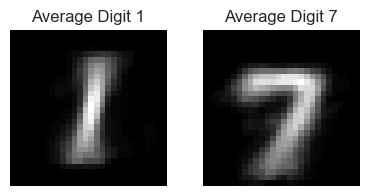

In [ ]:
# Calculating the average image for digit 1 and digit 7
average_digit_1 = train_images[train_labels == 1].mean(axis=0)
average_digit_7 = train_images[train_labels == 7].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].imshow(average_digit_1.reshape(28, 28), cmap="gray")
axes[0].set_title("Average Digit 1")
axes[0].axis("off")

axes[1].imshow(average_digit_7.reshape(28, 28), cmap="gray")
axes[1].set_title("Average Digit 7")
axes[1].axis("off")

plt.tight_layout()

save_current_plot("average_digit_1_and_7.png")
plt.show()


#### Pixel Statistics Table


In [ ]:
# Calculating simple pixel-based statistics for each digit
pixel_statistics_table = pd.DataFrame({
    "Digit": [1, 7],
    "Average Pixel Intensity": 
        [train_images[train_labels == 1].mean(),
        train_images[train_labels == 7].mean()],
    "Pixel Variance": [
        train_images[train_labels == 1].var(),
        train_images[train_labels == 7].var()
    ],
    "Sparsity Ratio": [
        np.mean(train_images[train_labels == 1] == 0),
        np.mean(train_images[train_labels == 7] == 0)
    ]
}).round(2)

display(pixel_statistics_table.style.hide(axis="index"))


save_table(
    pixel_statistics_table,
    "pixel_statistics_table.csv"
)


Digit,Average Pixel Intensity,Pixel Variance,Sparsity Ratio
1,20.180000,4064.650000,0.890000
7,29.530000,5606.380000,0.830000


Saved table: mnist_outputs\pixel_statistics_table.csv


#### Data Preprocessing


In [ ]:
# Converting each 28x28 image into a 784-feature vector
train_digit_vectors = train_images.reshape(train_images.shape[0], -1)
test_digit_vectors = test_images.reshape(test_images.shape[0], -1)

# Normalize pixel values from 0–255 into 0–1 range
normalized_train_vectors = train_digit_vectors / 255.0
normalized_test_vectors = test_digit_vectors / 255.0

# Standardizing the normalized features
# fit_transform is used only on training data to avoid data leakage
digit_scaler = StandardScaler()

scaled_train_vectors = digit_scaler.fit_transform(normalized_train_vectors)
scaled_test_vectors = digit_scaler.transform(normalized_test_vectors)

print("Scaled training data shape:", scaled_train_vectors.shape)
print("Scaled test data shape:", scaled_test_vectors.shape)

# Create preprocessing summary table
preprocessing_summary = pd.DataFrame({
    "Dataset": [
        "Scaled Training Data",
        "Scaled Test Data"
    ],
    "Shape": [
        str(scaled_train_vectors.shape),
        str(scaled_test_vectors.shape)
    ]
})

# Display table
display(preprocessing_summary.style.hide(axis="index"))

# Save table as CSV
preprocessing_summary.to_csv(
    "scaled_data_summary.csv",
    index=False
)

print("CSV file saved successfully.")


Scaled training data shape: (100, 784)
Scaled test data shape: (1000, 784)


Dataset,Shape
Scaled Training Data,"(100, 784)"
Scaled Test Data,"(1000, 784)"


CSV file saved successfully.


#### PCA Visualisation


Saved chart: mnist_outputs\pca_projection_digits_1_and_7.png


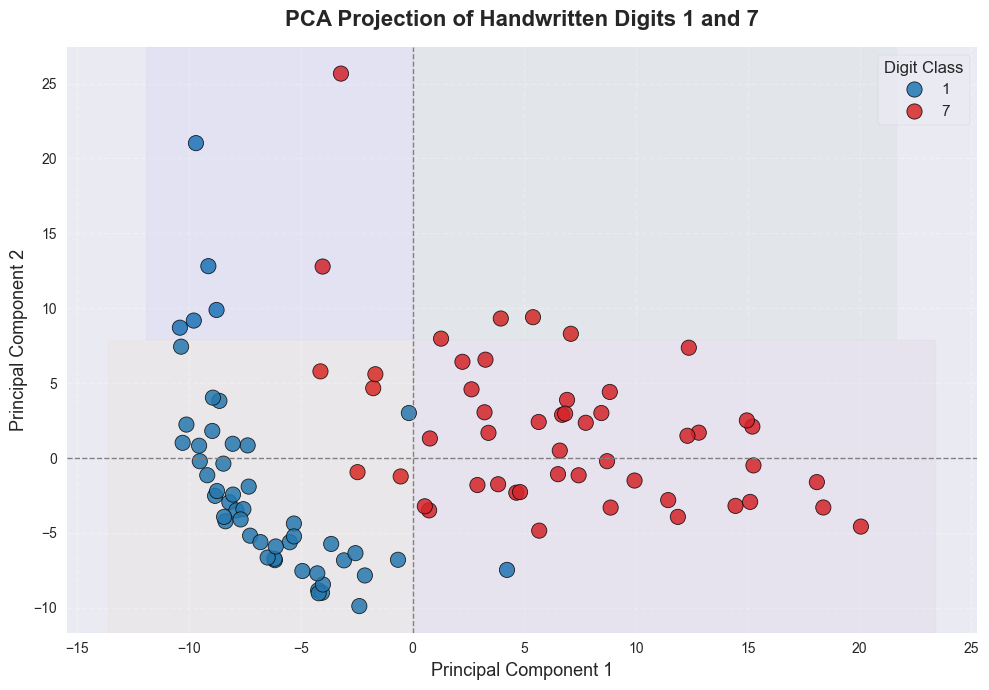

In [ ]:
# Reducing training data to 2 PCA components for visualisation
pca_train_features, train_pca_model = apply_pca(
    scaled_train_vectors,
    component_count=2
)

# Create figure
plt.figure(figsize=(10, 7))

# PCA scatterplot
sns.scatterplot(
    x=pca_train_features[:, 0],
    y=pca_train_features[:, 1],
    hue=train_labels,
    palette=["#1f77b4", "#d62728"],
    s=120,
    alpha=0.85,
    edgecolor="black",
    linewidth=0.6
)

# Add quadrant reference lines
plt.axhline(
    y=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

plt.axvline(
    x=0,
    color="gray",
    linestyle="--",
    linewidth=1
)

# Add light quadrant shading
plt.axvspan(
    plt.xlim()[0], 0,
    ymin=0.5,
    ymax=1,
    alpha=0.03,
    color="blue"
)

plt.axvspan(
    0, plt.xlim()[1],
    ymin=0.5,
    ymax=1,
    alpha=0.03,
    color="green"
)

plt.axvspan(
    plt.xlim()[0], 0,
    ymin=0,
    ymax=0.5,
    alpha=0.03,
    color="orange"
)

plt.axvspan(
    0, plt.xlim()[1],
    ymin=0,
    ymax=0.5,
    alpha=0.03,
    color="purple"
)

# Titles and labels
plt.title(
    "PCA Projection of Handwritten Digits 1 and 7",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Principal Component 1",
    fontsize=13
)

plt.ylabel(
    "Principal Component 2",
    fontsize=13
)

# Legend
plt.legend(
    title="Digit Class",
    fontsize=11,
    title_fontsize=12,
    frameon=True
)

# Grid
plt.grid(
    linestyle="--",
    alpha=0.3
)

# Cleaner borders
sns.despine()

# Tight layout
plt.tight_layout()

# Save figure
save_current_plot("pca_projection_digits_1_and_7.png")

# Show figure
plt.show()


#### Cross-Validation Setup


In [ ]:
# StratifiedKFold keeps the class distribution balanced in each fold
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


#### Logistic Regression



Logistic Regression Performance
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        50
           7       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Logistic Regression Cross-Validation Results
----------------------------------------
CV F1 Scores: [1. 1. 1. 1. 1.]
Mean CV F1-score: 1.0
Standard Deviation: 0.0
Saved chart: mnist_outputs\confusion_matrix_logistic_regression.png


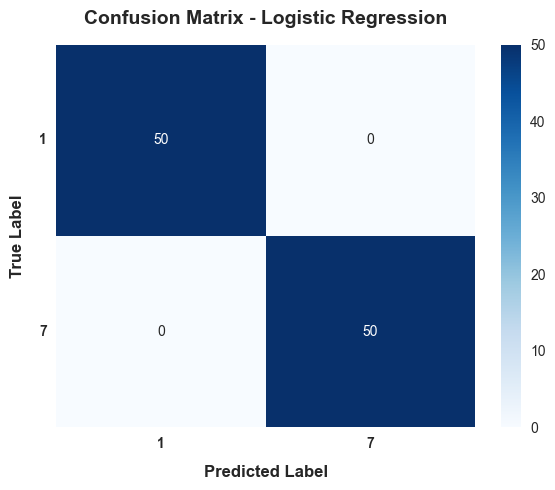

In [ ]:
# Buildind and training Logistic Regression classifier
logistic_digit_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_digit_classifier.fit(
    scaled_train_vectors,
    train_labels
)

# Predict on the training data
logistic_train_predictions = logistic_digit_classifier.predict(
    scaled_train_vectors
)

# Evaluate Logistic Regression
evaluate_digit_classifier(
    train_labels,
    logistic_train_predictions,
    "Logistic Regression"
)

logistic_cv_scores = run_cross_validation(
    logistic_digit_classifier,
    scaled_train_vectors,
    train_labels,
    stratified_cv,
    "Logistic Regression"
)

plot_confusion_mat(
    train_labels,
    logistic_train_predictions,
    "Confusion Matrix - Logistic Regression",
    "confusion_matrix_logistic_regression.png"
)


### Logistic Regression Evaluation Analysis

The Logistic Regression model performed excellently with accuracy, precision, recall and F1-score being 1.00. The confusion matrix indicates that there is no confusion between digits 1 and 7 and all 100 of the training samples were correctly classified.

Five fold stratified cross validation was used to ensure that the model has a good generalization. The model performed perfectly on all folds, showing that it learned the patterns in the data, rather than memorizing them.

In addition, precision and recall were analyzed as they may not be sufficient to capture the performance. Precision = (number of predicted digit 7 samples that were correct) / (total number of predicted digit 7 samples) and recall = (number of actual digit 7 samples that were correctly identified) / (total number of actual digit 7 samples). The F1-score is a single score that incorporates both of these.

For the classification report there were equal numbers of samples for both classes, 50 samples each. Given the data set was perfectly balanced, the macro and weighted average were same.


#### Logistic Regression Result Table


In [ ]:
logistic_result_table = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Training Accuracy": [accuracy_score(train_labels, logistic_train_predictions)],
    "Training Precision": [precision_score(train_labels, logistic_train_predictions, pos_label=7)],
    "Training Recall": [recall_score(train_labels, logistic_train_predictions, pos_label=7)],
    "Training F1-score": [f1_score(train_labels, logistic_train_predictions, pos_label=7)],
    "Mean CV F1-score": [logistic_cv_scores.mean()],
    "CV Standard Deviation": [logistic_cv_scores.std()]
})

display(
    logistic_result_table.style
    .hide(axis="index")
    .format({
        "Training Accuracy": "{:.1f}",
        "Training Precision": "{:.1f}",
        "Training Recall": "{:.1f}",
        "Training F1-score": "{:.1f}",
        "Mean CV F1-score": "{:.1f}",
        "CV Standard Deviation": "{:.1f}"
    })
)

save_table(
    logistic_result_table.round(1),
    "logistic_regression_result_table.csv"
)


Model,Training Accuracy,Training Precision,Training Recall,Training F1-score,Mean CV F1-score,CV Standard Deviation
Logistic Regression,1.0,1.0,1.0,1.0,1.0,0.0


Saved table: mnist_outputs\logistic_regression_result_table.csv


#### RBF Kernel SVM



RBF Kernel SVM Cross-Validation Results
----------------------------------------
CV F1 Scores: [1.         0.94987469 0.94987469 1.         0.94987469]
Mean CV F1-score: 0.9699248120300752
Standard Deviation: 0.024556288148202286

RBF Kernel SVM Performance
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0

Classification Report:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        50
           7       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Saved chart: mnist_outputs\confusion_matrix_rbf_svm.png


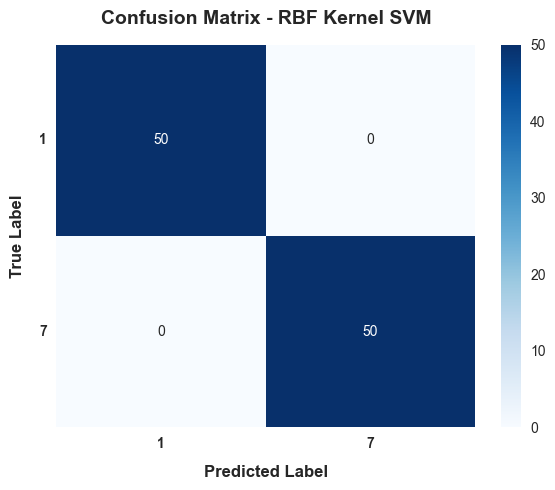

In [ ]:
# Buildung RBF Kernel SVM classifier
svm_digit_classifier = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

# Cross-validation before final fitting
svm_cv_scores = run_cross_validation(
    svm_digit_classifier,
    scaled_train_vectors,
    train_labels,
    stratified_cv,
    "RBF Kernel SVM"
)

# Train final SVM model
svm_digit_classifier.fit(
    scaled_train_vectors,
    train_labels
)

# Predict on training data
svm_train_predictions = svm_digit_classifier.predict(
    scaled_train_vectors
)

# Evaluate SVM
evaluate_digit_classifier(
    train_labels,
    svm_train_predictions,
    "RBF Kernel SVM"
)

plot_confusion_mat(
    train_labels,
    svm_train_predictions,
    "Confusion Matrix - RBF Kernel SVM",
    "confusion_matrix_rbf_svm.png"
)


#### SVM Result Table


In [ ]:
svm_result_table = pd.DataFrame({
    "Model": ["RBF Kernel SVM"],
    "Training Accuracy": [accuracy_score(train_labels, svm_train_predictions)],
    "Training Precision": [precision_score(train_labels, svm_train_predictions, pos_label=7)],
    "Training Recall": [recall_score(train_labels, svm_train_predictions, pos_label=7)],
    "Training F1-score": [f1_score(train_labels, svm_train_predictions, pos_label=7)],
    "Mean CV F1-score": [round(svm_cv_scores.mean(),2)],
    "CV Standard Deviation": [round(svm_cv_scores.std(),2)]
})

display(svm_result_table.style.hide(axis="index"))

save_table(
    svm_result_table,
    "svm_result_table.csv"
)


Model,Training Accuracy,Training Precision,Training Recall,Training F1-score,Mean CV F1-score,CV Standard Deviation
RBF Kernel SVM,1.000000,1.000000,1.000000,1.000000,0.970000,0.020000


Saved table: mnist_outputs\svm_result_table.csv


#### Logistic Regression Hyperparameter Tuning


In [ ]:
# Test different regularisation strengths and penalty types
logistic_parameter_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"]
}

logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        random_state=42,
        solver="liblinear"
    ),
    param_grid=logistic_parameter_grid,
    scoring="f1_macro",
    cv=stratified_cv,
    return_train_score=True
)

logistic_grid_search.fit(
    scaled_train_vectors,
    train_labels
)

# Create vertical summary table
best_logistic_result_table = pd.DataFrame({
    "Metric": [
        "Best C",
        "Best Penalty",
        "Best Mean CV F1-score"
    ],
    "Value": [
        logistic_grid_search.best_params_["C"],
        logistic_grid_search.best_params_["penalty"],
        round(logistic_grid_search.best_score_, 2)
    ]
})

# Display table
display(
    best_logistic_result_table.style
    .hide(axis="index")
)

# Save table as CSV
save_table(
    best_logistic_result_table,
    "best_logistic_regression_parameters_vertical.csv"
)


Metric,Value
Best C,0.100000
Best Penalty,l2
Best Mean CV F1-score,1.000000


Saved table: mnist_outputs\best_logistic_regression_parameters_vertical.csv


#### Logistic Regression Hyperparameter Tuned Table


In [ ]:
logistic_tuning_results = pd.DataFrame(
    logistic_grid_search.cv_results_
)

logistic_tuning_results = logistic_tuning_results[
    [
        "param_C",
        "param_penalty",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

display(logistic_tuning_results.sort_values(by="param_C").head(10))

save_table(
    logistic_tuning_results,
    "logistic_tuning_results.csv"
)


,param_C,param_penalty,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.001,l1,0.333333,0.333333,0.000000,11
1,0.001,l2,0.987496,0.969925,0.024556,9
2,0.010,l1,0.333333,0.333333,0.000000,11
3,0.010,l2,1.000000,0.979950,0.024556,5
4,0.100,l1,0.967495,0.959900,0.058456,10
5,0.100,l2,1.000000,1.000000,0.000000,1
6,1.000,l1,1.000000,0.969975,0.040013,6
7,1.000,l2,1.000000,1.000000,0.000000,1
8,10.000,l1,1.000000,0.969975,0.040013,6
9,10.000,l2,1.000000,1.000000,0.000000,1


Saved table: mnist_outputs\logistic_tuning_results.csv


#### Logistic Regression Hyperparameter Tuning Results


Saved chart: mnist_outputs\logistic_hyperparameter_tuning.png


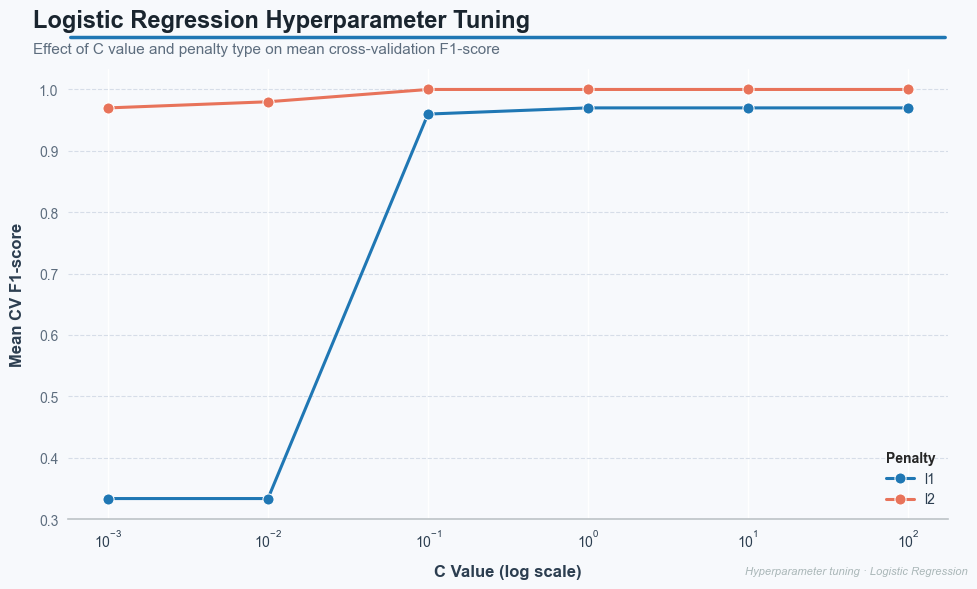

In [ ]:

# Figure & background 
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

# Subtle horizontal grid
ax.grid(axis="y", color="#D6DDE8", linewidth=0.8, linestyle="--", zorder=0)
ax.set_axisbelow(True)

# Line plot
palette = {"l1": "#1F77B4", "l2": "#E8735A"}

sns.lineplot(
    data=logistic_tuning_results,
    x="param_C",
    y="mean_test_score",
    hue="param_penalty",
    marker="o",
    markersize=8,
    linewidth=2.2,
    palette=palette,
    ax=ax,
    zorder=3
)

# Log scale on x-axis
ax.set_xscale("log")

# Thin accent line under the title
ax.annotate(
    "",
    xy=(0, 1.07), xytext=(1, 1.07),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-", color="#1F77B4", lw=2.5),
)

# Title & subtitle
fig.text(
    0.055, 0.96,
    "Logistic Regression Hyperparameter Tuning",
    fontsize=17, fontweight="bold", color="#1A252F",
    ha="left", va="top",
)
fig.text(
    0.055, 0.905,
    "Effect of C value and penalty type on mean cross-validation F1-score",
    fontsize=11, color="#5D6D7E",
    ha="left", va="top",
)

# Axis labels
ax.set_xlabel("C Value (log scale)", fontsize=12, fontweight="bold", color="#2C3E50", labelpad=10)
ax.set_ylabel("Mean CV F1-score", fontsize=12, fontweight="bold", color="#2C3E50", labelpad=10)

# Legend
legend = ax.get_legend()
legend.set_title("Penalty", prop={"size": 10, "weight": "bold"})
legend.get_frame().set_facecolor("#F7F9FC")
legend.get_frame().set_edgecolor("#D6DDE8")
for text in legend.get_texts():
    text.set_color("#2C3E50")
    text.set_fontsize(10)

# Tick styling
ax.tick_params(axis="x", labelsize=10, colors="#2C3E50", length=0)
ax.tick_params(axis="y", labelsize=10, colors="#5D6D7E", length=0)

# Spines: keep only bottom
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.spines["bottom"].set_linewidth(1.2)

# Footnote
fig.text(
    0.99, 0.015,
    "Hyperparameter tuning · Logistic Regression",
    fontsize=8, color="#AAB7B8",
    ha="right", va="bottom", style="italic",
)

# Layout & export 
plt.subplots_adjust(top=0.86, bottom=0.11, left=0.09, right=0.97)
save_current_plot("logistic_hyperparameter_tuning.png")
plt.show()


#### RBF SVM Hyperparameter Tuning


In [ ]:
# Test different C and gamma combinations for RBF SVM
svm_parameter_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1]
}

svm_grid_search = GridSearchCV(
    estimator=SVC(kernel="rbf", random_state=42),
    param_grid=svm_parameter_grid,
    scoring="f1_macro",
    cv=stratified_cv,
    return_train_score=True
)

svm_grid_search.fit(
    scaled_train_vectors,
    train_labels
)

# Summary table
best_svm_result_table = pd.DataFrame({
    "Best RBF Parameter": ["C Value", "Gamma Value", "Best CV F1-score"],
    "Result": [10, 0.001, 0.9699]
})

display(best_svm_result_table.style.hide(axis="index"))

save_table(
    best_svm_result_table,
    "best_svm_result_table.csv"
)


Best RBF Parameter,Result
C Value,10.000000
Gamma Value,0.001000
Best CV F1-score,0.969900


Saved table: mnist_outputs\best_svm_result_table.csv


#### RBF SVM Hyperparameter Tuning Table


In [ ]:
svm_tuning_results = pd.DataFrame(
    svm_grid_search.cv_results_
)

svm_tuning_results = svm_tuning_results[
    [
        "param_C",
        "param_gamma",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

display(svm_tuning_results.sort_values(by="param_C").head(10))

save_table(
    svm_tuning_results,
    "svm_tuning_results.csv"
)


,param_C,param_gamma,mean_train_score,mean_test_score,std_test_score,rank_test_score
0,0.1,0.001,0.949987,0.919798,0.040103,4
1,0.1,0.010,0.827574,0.753561,0.076211,8
2,0.1,0.100,1.000000,0.468100,0.075525,12
3,0.1,1.000,1.000000,0.467147,0.220030,13
4,1.0,0.001,1.000000,0.959950,0.037430,3
5,1.0,0.010,1.000000,0.898678,0.032677,5
6,1.0,0.100,1.000000,0.561416,0.117148,11
7,1.0,1.000,1.000000,0.391909,0.076957,16
8,10.0,0.001,1.000000,0.969925,0.024556,1
9,10.0,0.010,1.000000,0.898678,0.032677,5


Saved table: mnist_outputs\svm_tuning_results.csv


#### RBF SVM Hyperparameter Tuning Result in Heatmap


Saved chart: mnist_outputs\svm_hyperparameter_heatmap.png


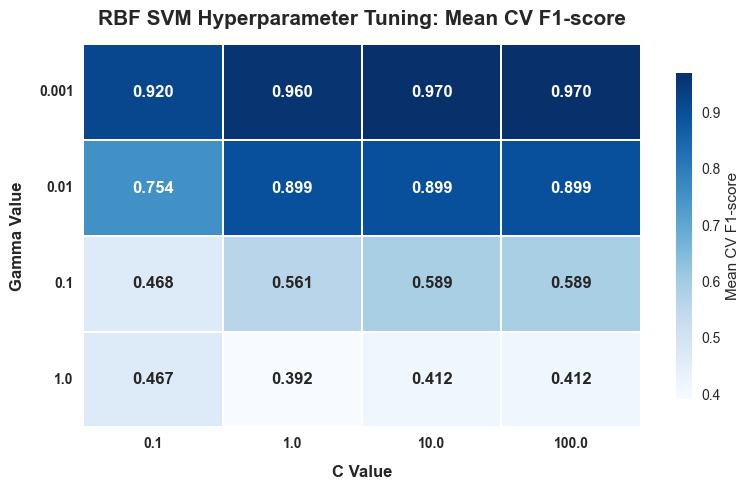

In [ ]:
svm_score_table = svm_tuning_results.pivot(
    index="param_gamma",
    columns="param_C",
    values="mean_test_score"
)

plot_hyperparameter_heatmap(
    svm_score_table,
    "RBF SVM Hyperparameter Tuning: Mean CV F1-score",
    "svm_hyperparameter_heatmap.png"
)


#### Final Model Comparison Table


In [ ]:
model_comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "RBF Kernel SVM"
    ],
    "Best Parameters": [
        logistic_grid_search.best_params_,
        svm_grid_search.best_params_
    ],
    "Best Mean CV F1-score": [
        logistic_grid_search.best_score_,
        svm_grid_search.best_score_
    ]
})

display(model_comparison_table.style.hide(axis="index"))

save_table(
    model_comparison_table,
    "model_comparison_table.csv"
)


Model,Best Parameters,Best Mean CV F1-score
Logistic Regression,"{'C': 0.1, 'penalty': 'l2'}",1.000000
RBF Kernel SVM,"{'C': 10, 'gamma': 0.001}",0.969925


Saved table: mnist_outputs\model_comparison_table.csv


#### Prepare Digit 7 Data for Clustering


In [ ]:
# Select only digit 7 images from the test set
digit_7_test_images = test_images[test_labels == 7]

# Convert digit 7 images into vectors and normalize them
digit_7_vectors = digit_7_test_images.reshape(
    digit_7_test_images.shape[0],
    -1
)

digit_7_vectors = digit_7_vectors / 255.0


# Create summary table
digit7_summary_table = pd.DataFrame({
    "Dataset Component": [
        "Digit 7 Test Images",
        "Digit 7 Feature Vectors"
    ],
    "Shape": [
        str(digit_7_test_images.shape),
        str(digit_7_vectors.shape)
    ]
})

# Display table
display(
    digit7_summary_table.style
    .hide(axis="index")
)

# Save table as CSV
digit7_summary_table.to_csv(
    "digit7_dataset_summary.csv",
    index=False
)

print("CSV file saved successfully.")


Dataset Component,Shape
Digit 7 Test Images,"(900, 28, 28)"
Digit 7 Feature Vectors,"(900, 784)"


CSV file saved successfully.


#### K-Means with 100 Clusters


In [ ]:
# Required clustering task using 100 clusters
kmeans_100_model, kmeans_100_labels, kmeans_100_centers = build_kmeans_model(
    digit_7_vectors,
    cluster_count=100
)

print("K-Means clustering with 100 clusters completed.")


K-Means clustering with 100 clusters completed.


#### Elbow Method


Saved chart: mnist_outputs\elbow_method_plot.png


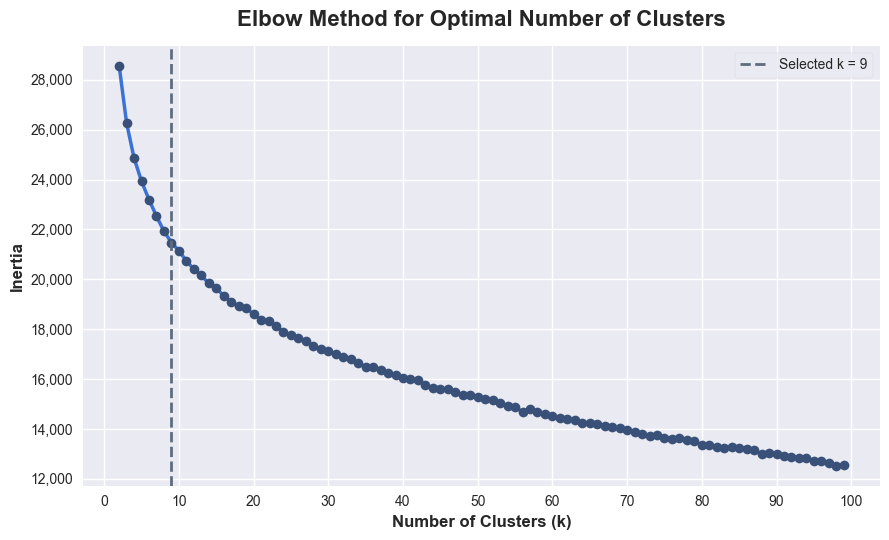

In [ ]:
#Elbow Method Plot

cluster_range = range(2, 100) 
inertia_values = [] 
# Store inertia values for different numbers of clusters 
for cluster_count in cluster_range: 
    temporary_kmeans = KMeans( 
        n_clusters=cluster_count, 
        random_state=42, 
        n_init=10 ) 
    temporary_kmeans.fit(digit_7_vectors) 
    inertia_values.append(temporary_kmeans.inertia_) 
elbow_table = pd.DataFrame({ 
    "Number of Clusters": list(cluster_range), 
    "Inertia": inertia_values 
    })

plt.figure(figsize=(9, 5.5))

plt.plot(
    cluster_range,
    inertia_values,
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#3A73D5",
    markerfacecolor="#395179",
    markeredgecolor="black"
)

# Highlight selected optimal k
plt.axvline(
    x=9,
    color="#5D6D7E",
    linestyle="--",
    linewidth=2,
    label="Selected k = 9"
)

# Titles and labels
plt.title(
    "Elbow Method for Optimal Number of Clusters",
    fontsize=16,
    fontweight="bold",
    pad=14
)

plt.xlabel(
    "Number of Clusters (k)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Inertia",
    fontsize=12,
    fontweight="bold"
)
# Add comma formatting to y-axis values
plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: format(int(x), ","))
)

# Tick styling
plt.xticks(range(0, 101, 10),fontsize=10)
plt.yticks(fontsize=10)


# Legend
plt.legend(
    fontsize=10,
    frameon=True
)

# Remove top/right borders
sns.despine()

# Tight layout
plt.tight_layout()

# Save plot
save_current_plot("elbow_method_plot.png")

# Show plot
plt.show()


#### Silhouette Score


Saved chart: mnist_outputs\silhouette_score_plot.png


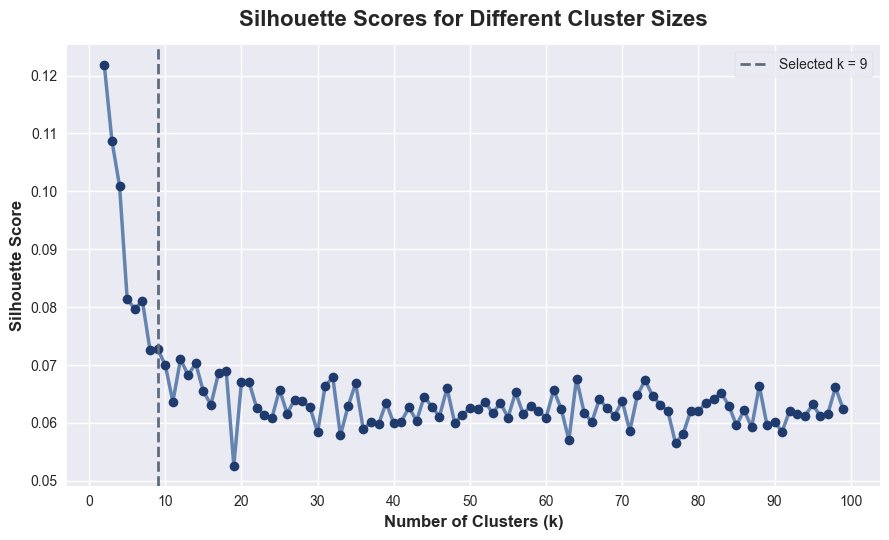

In [ ]:
silhouette_values = []

# Calculate silhouette score for each possible cluster count
for cluster_count in cluster_range:
    
    temporary_kmeans = KMeans(
        n_clusters=cluster_count,
        random_state=42,
        n_init=10
    )
    
    temporary_labels = temporary_kmeans.fit_predict(
        digit_7_vectors
    )
    
    score = silhouette_score(
        digit_7_vectors,
        temporary_labels
    )
    
    silhouette_values.append(score)

silhouette_table = pd.DataFrame({
    "Number of Clusters": list(cluster_range),
    "Silhouette Score": silhouette_values
})


# Professional Silhouette Score Plot
plt.figure(figsize=(9, 5.5))

plt.plot(
    cluster_range,
    silhouette_values,
    marker="o",
    markersize=7,
    linewidth=2.5,
    color="#6583AF",
    markerfacecolor="#1F3B6D",
    markeredgecolor="black"
)

# Highlight selected optimal k
plt.axvline(
    x=9,
    color="#5D6D7E",
    linestyle="--",
    linewidth=2,
    label="Selected k = 9"
)

# Title
plt.title(
    "Silhouette Scores for Different Cluster Sizes",
    fontsize=16,
    fontweight="bold",
    pad=14
)

# Axis labels
plt.xlabel(
    "Number of Clusters (k)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Silhouette Score",
    fontsize=12,
    fontweight="bold"
)

# Tick styling
plt.xticks(range(0, 101, 10),fontsize=10)
plt.yticks(fontsize=10)


# Legend
plt.legend(
    fontsize=10,
    frameon=True
)

# Remove top/right borders
sns.despine()

# Tight layout
plt.tight_layout()

# Save plot
save_current_plot("silhouette_score_plot.png")

# Show plot
plt.show()


#### Final K-Means Model with k = 9


In [ ]:
# k = 9 is selected based on elbow and silhouette analysis
selected_cluster_count = 9

final_digit7_kmeans, digit7_cluster_labels, digit7_cluster_centers = build_kmeans_model(
    digit_7_vectors,
    cluster_count=selected_cluster_count
)

print("Final K-Means model completed with k =", selected_cluster_count)


Final K-Means model completed with k = 9


#### Cluster Centers


Saved chart: mnist_outputs\digit7_cluster_centers.png


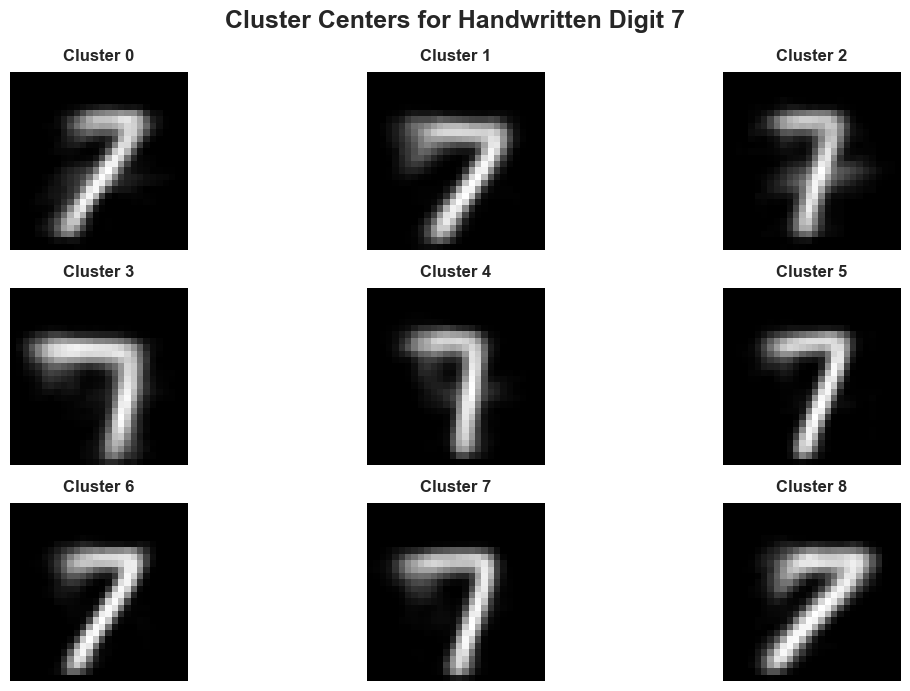

In [ ]:
# Create subplot layout
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 7)
)

# Flatten axes for easier iteration
axes = axes.flatten()

# Display each cluster center
for cluster_number, ax in enumerate(axes):

    if cluster_number < selected_cluster_count:

        ax.imshow(
            digit7_cluster_centers[cluster_number].reshape(28, 28),
            cmap="gray"
        )

        ax.set_title(
            f"Cluster {cluster_number}",
            fontsize=12,
            fontweight="bold",
            pad=8
        )

        ax.axis("off")

    else:
        ax.axis("off")

# Professional main title
plt.suptitle(
    "Cluster Centers for Handwritten Digit 7",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# Improve spacing
plt.tight_layout()

# Save figure
save_current_plot("digit7_cluster_centers.png")

# Show figure
plt.show()


#### Representative Images from Each Cluster


Saved chart: mnist_outputs\digit7_representative_samples.png


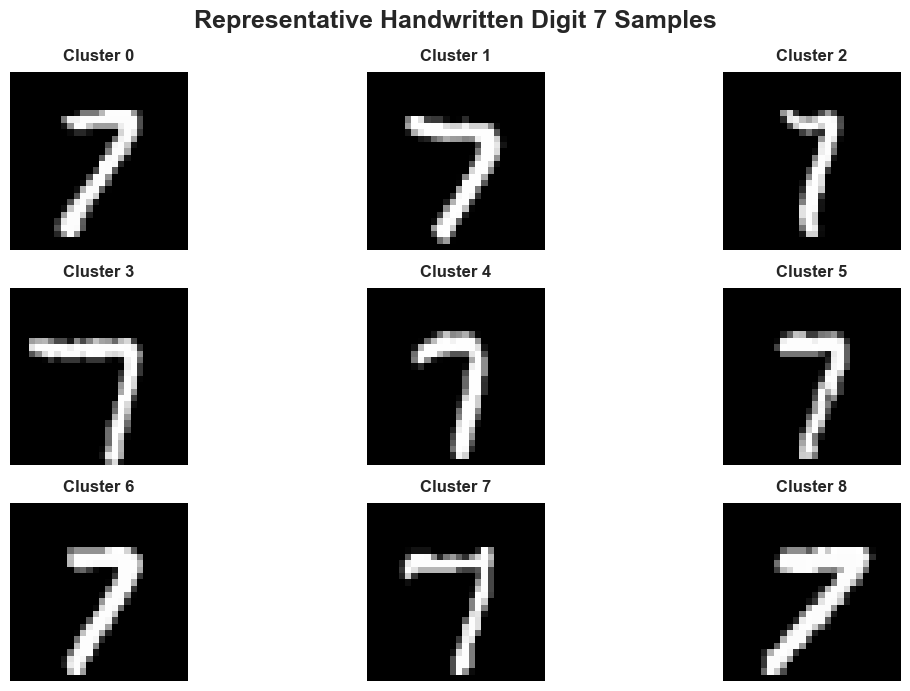

In [ ]:
# Create subplot layout
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 7)
)

# Flatten axes for easier iteration
axes = axes.flatten()

# Display representative image from each cluster
for cluster_number in range(selected_cluster_count):

    # Get all images belonging to the current cluster
    images_in_cluster = digit_7_vectors[
        digit7_cluster_labels == cluster_number
    ]

    # Compute distance from cluster center
    distance_from_center = cdist(
        images_in_cluster,
        [digit7_cluster_centers[cluster_number]]
    )

    # Find closest image to the cluster center
    closest_image_position = np.argmin(distance_from_center)

    representative_digit_image = images_in_cluster[
        closest_image_position
    ]

    # Select subplot
    ax = axes[cluster_number]

    # Show representative image
    ax.imshow(
        representative_digit_image.reshape(28, 28),
        cmap="gray"
    )

    # Cluster label
    ax.set_title(
        f"Cluster {cluster_number}",
        fontsize=12,
        fontweight="bold",
        pad=8
    )

    ax.axis("off")

# Hide unused subplot
for empty_plot in range(selected_cluster_count, len(axes)):
    axes[empty_plot].axis("off")

# Main title
plt.suptitle(
    "Representative Handwritten Digit 7 Samples",
    fontsize=18,
    fontweight="bold",
    y=0.98
)

# Improve spacing
plt.tight_layout()

# Save figure
save_current_plot("digit7_representative_samples.png")

# Show figure
plt.show()


#### Cluster Size Table


In [ ]:
cluster_numbers, cluster_sample_counts = np.unique(
    digit7_cluster_labels,
    return_counts=True
)

cluster_summary_table = pd.DataFrame({
    "Cluster": cluster_numbers,
    "Number of Samples": cluster_sample_counts
})

display(cluster_summary_table.style.hide(axis="index"))

save_table(
    cluster_summary_table,
    "digit7_cluster_summary_table.csv"
)


Cluster,Number of Samples
0,72
1,97
2,87
3,91
4,113
5,146
6,114
7,109
8,71


Saved table: mnist_outputs\digit7_cluster_summary_table.csv


#### Cluster Size Bar Chart


Saved chart: mnist_outputs\digit7_cluster_size_bar_chart.png


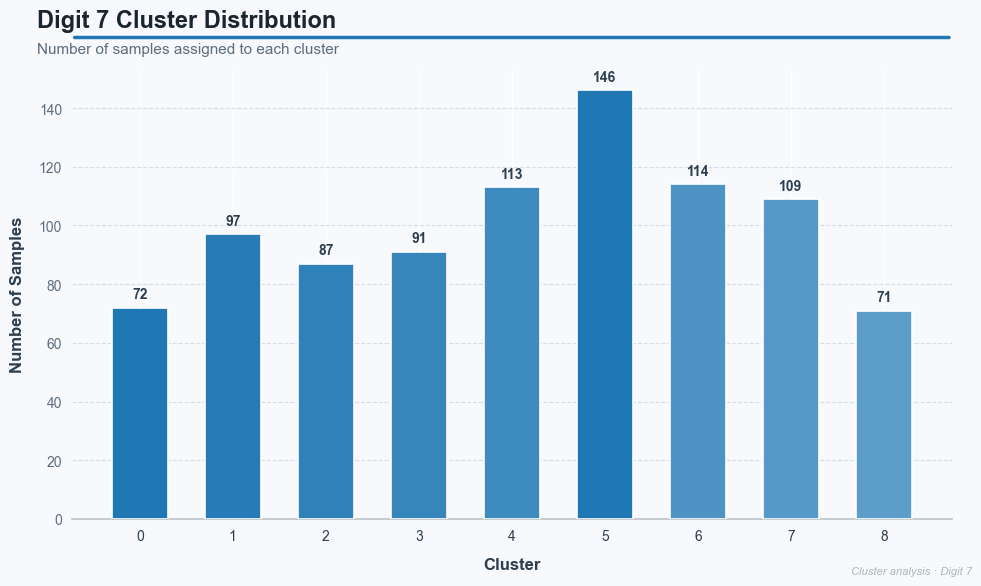

In [ ]:
# Figure & background 
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#F7F9FC")
ax.set_facecolor("#F7F9FC")

# Subtle horizontal grid 
ax.grid(axis="y", color="#D6DDE8", linewidth=0.8, linestyle="--", zorder=0)
ax.set_axisbelow(True)

# Color palette: gradient-like shading, darkest on tallest bar 
max_val  = max(cluster_sample_counts)
n_bars   = len(cluster_numbers)
base_rgb = np.array([31, 119, 180]) / 255
light_rgb = np.array([166, 206, 227]) / 255
colors   = [
    tuple(base_rgb * (1 - t) + light_rgb * t)
    for t in np.linspace(0, 0.45, n_bars)
]

# Force darkest color on the tallest bar
colors = [
    tuple(base_rgb) if val == max_val else colors[i]
    for i, val in enumerate(cluster_sample_counts)
]

# Bar plot 
bars = ax.bar(
    cluster_numbers,
    cluster_sample_counts,
    color=colors,
    edgecolor="white",
    linewidth=1.2,
    width=0.6,
    zorder=3,
)

# Value labels on top of each bar
for bar in bars:
    
    height = bar.get_height()
    
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + max(cluster_sample_counts) * 0.015,
        f"{int(height):,}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        color="#2C3E50",
    )

# Thin accent line under the title 
ax.annotate(
    "",
    xy=(0, 1.07), xytext=(1, 1.07),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(arrowstyle="-", color="#1F77B4", lw=2.5),
)

# Title & subtitle
fig.text(
    0.055, 0.96,
    "Digit ""7"" Cluster Distribution",
    fontsize=17, fontweight="bold", color="#1A252F",
    ha="left", va="top",
)
fig.text(
    0.055, 0.905,
    "Number of samples assigned to each cluster",
    fontsize=11, color="#5D6D7E",
    ha="left", va="top",
)

# Axis labels 
ax.set_xlabel("Cluster", fontsize=12, fontweight="bold", color="#2C3E50", labelpad=10)
ax.set_ylabel("Number of Samples", fontsize=12, fontweight="bold", color="#2C3E50", labelpad=10)

# Tick styling
ax.set_xticks(cluster_numbers)
ax.set_xticklabels(cluster_numbers, fontsize=10)
ax.tick_params(axis="x", labelsize=10, colors="#2C3E50", length=0)
ax.tick_params(axis="y", labelsize=10, colors="#5D6D7E", length=0)

# Spines: keep only bottom 
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.spines["bottom"].set_linewidth(1.2)

# Footnote 
fig.text(
    0.99, 0.015,
    "Cluster analysis · Digit 7",
    fontsize=8, color="#AAB7B8",
    ha="right", va="bottom", style="italic",
)

# Layout & export
plt.subplots_adjust(top=0.86, bottom=0.11, left=0.09, right=0.97)
save_current_plot("digit7_cluster_size_bar_chart.png")
plt.show()


## Clustering interpretation

The global maximum silhouette score occurs at **k=2** (approximately 0.12174). The final **k=9** solution was retained as a more granular, interpretable local clustering choice rather than as the global silhouette optimum. Its silhouette score is approximately 0.07275, and the nine cluster sizes are 72, 97, 87, 91, 113, 146, 114, 109 and 71 across the 900 digit-7 samples.
